### ML Mini Project - Intelligent Business Analytics and Forecasting System

<div style="font-size:14px; line-height:1.6">
This notebook implements the YAML modules in a clean and simple structure.
</div>

#### 1. Project Overview"
- Predictive modeling: "Regression" + "Classification"
- Customer segmentation: "Clustering"
- Review analytics: "NLP"
- Sales/load prediction: "Time Series"


### Setup
<div style="font-size:14px; line-height:1.6">
Simple imports for data, modeling, NLP, and forecasting.
</div>

In [ ]:
# Purpose: setup core libraries used across all YAML modules.
# Libraries: pandas, numpy, matplotlib, seaborn, scikit-learn, statsmodels, nltk.

import warnings
warnings.filterwarnings("ignore")

import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    silhouette_score,
)
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

# YAML-required library: Prophet is required for time-series module.
from prophet import Prophet

# Optional library for NLP NER examples.
try:
    from transformers import pipeline
    TRANSFORMERS_AVAILABLE = True
except Exception:
    TRANSFORMERS_AVAILABLE = False

# Runtime configuration for faster training.
TRAIN_SAMPLE_FRAC = 0.5
RF_TREES_FAST = 120
KMEANS_MAX_K = 8

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

Importing plotly failed. Interactive plots will not work.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [26]:
# Purpose: download lightweight NLTK resources required for tokenization and sentiment.
for pkg in ["punkt", "stopwords", "vader_lexicon"]:
    try:
        nltk.download(pkg, quiet=True)
    except Exception:
        pass

### Data Loading
4. Data Merging Strategy" starts with loading each relational table.


In [27]:
# Purpose: read all raw Olist datasets used by YAML use cases.
# Library: pandas.
DATA_DIR = "datasets"

df_customers = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
df_orders = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv")
df_items = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")
df_payments = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
df_products = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
df_reviews = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv")
df_sellers = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
df_translation = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

print("customers:", df_customers.shape)
print("orders:", df_orders.shape)
print("items:", df_items.shape)
print("payments:", df_payments.shape)
print("products:", df_products.shape)
print("reviews:", df_reviews.shape)
print("sellers:", df_sellers.shape)

customers: (99441, 5)
orders: (99441, 8)
items: (112650, 7)
payments: (103886, 5)
products: (32951, 9)
reviews: (99224, 7)
sellers: (3095, 4)


In [28]:
# Purpose: merge datasets in logical relational order and keep only required columns.
# Library: pandas.
df = df_orders.merge(df_customers, on="customer_id", how="left")
df = df.merge(df_items, on="order_id", how="left")
df = df.merge(df_products, on="product_id", how="left")
df = df.merge(df_translation, on="product_category_name", how="left")
df = df.merge(df_sellers, on="seller_id", how="left", suffixes=("", "_seller"))
df = df.merge(df_payments, on="order_id", how="left")
df = df.merge(df_reviews, on="order_id", how="left")

df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")

for col in [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]:
    df[col] = pd.to_datetime(df[col], errors="coerce")

# YAML target for revenue module.
df["total_order_value"] = df["price"].fillna(0) + df["freight_value"].fillna(0)

required_cols = [
    "order_id", "customer_id", "customer_unique_id",
    "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date",
    "customer_state", "seller_state", "customer_city", "seller_city",
    "product_id", "product_category_name_english", "price", "freight_value", "product_weight_g",
    "payment_type", "payment_installments", "payment_value",
    "review_comment_message", "review_score",
    "total_order_value",
]

keep_cols = [c for c in required_cols if c in df.columns]
df = df[keep_cols].copy()

# Replace state abbreviations with full names for readability.
state_name_map = {
    "AC": "Acre", "AL": "Alagoas", "AP": "Amapa", "AM": "Amazonas", "BA": "Bahia",
    "CE": "Ceara", "DF": "Distrito Federal", "ES": "Espirito Santo", "GO": "Goias",
    "MA": "Maranhao", "MT": "Mato Grosso", "MS": "Mato Grosso do Sul", "MG": "Minas Gerais",
    "PA": "Para", "PB": "Paraiba", "PR": "Parana", "PE": "Pernambuco", "PI": "Piaui",
    "RJ": "Rio de Janeiro", "RN": "Rio Grande do Norte", "RS": "Rio Grande do Sul",
    "RO": "Rondonia", "RR": "Roraima", "SC": "Santa Catarina", "SP": "Sao Paulo",
    "SE": "Sergipe", "TO": "Tocantins",
}

df["customer_state"] = df["customer_state"].map(state_name_map).fillna(df["customer_state"])
df["seller_state"] = df["seller_state"].map(state_name_map).fillna(df["seller_state"])

df["customer_city"] = df["customer_city"].astype(str).str.title()
df["seller_city"] = df["seller_city"].astype(str).str.title()

# Use fewer rows for training to reduce runtime.
df_model = (
    df.sample(frac=TRAIN_SAMPLE_FRAC, random_state=42)
    .sort_values("order_purchase_timestamp")
    .reset_index(drop=True)
)

print("full merged shape:", df.shape)
print("training sample shape:", df_model.shape)
df_model.head(3)

full merged shape: (119143, 21)
training sample shape: (59572, 21)


,order_id,customer_id,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_state,seller_state,customer_city,seller_city,product_id,product_category_name_english,price,freight_value,product_weight_g,payment_type,payment_installments,payment_value,review_comment_message,review_score,total_order_value
0,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,b7d76e111c89f7ebf14761390f0f7d17,2016-09-04 21:15:19,NaT,2016-10-20,Roraima,Minas Gerais,Boa Vista,Monte Siao,f293394c72c9b5fafd7023301fc21fc2,furniture_decor,32.90,31.67,1800.0,credit_card,1.0,136.23,1 mes de atraso na entrega !!! ultima compra q...,1.0,64.57
1,2e7a8482f6fb09756ca50c10d7bfc047,08c5351a6aca1c1589a38f244edeee9d,b7d76e111c89f7ebf14761390f0f7d17,2016-09-04 21:15:19,NaT,2016-10-20,Roraima,Minas Gerais,Boa Vista,Monte Siao,c1488892604e4ba5cff5b4eb4d595400,furniture_decor,39.99,31.67,1400.0,credit_card,1.0,136.23,1 mes de atraso na entrega !!! ultima compra q...,1.0,71.66
2,e5fa5a7210941f7d56d0208e4e071d35,683c54fc24d40ee9f8a6fc179fd9856c,4854e9b3feff728c13ee5fc7d1547e92,2016-09-05 00:15:34,NaT,2016-10-28,Rio Grande do Sul,Parana,Passo Fundo,Curitiba,f3c2d01a84c947b078e32bbef0718962,telephony,59.50,15.56,700.0,credit_card,3.0,75.06,Comprei dois produtos desta loja parceira da l...,1.0,75.06


## Dataset Validation
<div style="font-size:14px; line-height:1.6">
Check "column accuracy" against YAML use cases. Also verify if "ColumnTransformer" is required.

Answer: "ColumnTransformer" is not required for this notebook because manual preprocessing is used per task.
</div>

In [29]:
# Purpose: verify merged dataset contains all columns needed by YAML tasks.
expected_cols = {
    "order_id", "customer_unique_id", "order_purchase_timestamp", "order_delivered_customer_date",
    "order_estimated_delivery_date", "customer_state", "seller_state", "customer_city", "seller_city",
    "price", "freight_value", "product_weight_g", "payment_type", "payment_installments", "payment_value",
    "review_comment_message", "review_score", "total_order_value"
}

missing_cols = sorted(expected_cols - set(df_model.columns))
print("missing columns:", missing_cols)
print("column check passed:", len(missing_cols) == 0)

missing columns: []
column check passed: True


### Supervised Learning Module - Regression

Use case: predict state-wise monthly sales using "LinearRegression", "Ridge", "Lasso", and "RandomForestRegressor".


In [30]:
# Purpose: train regression models for state-month sales.
# Libraries: pandas, scikit-learn.
df_reg = df_model.dropna(subset=["order_purchase_timestamp", "customer_state"]).copy()
df_reg["order_month"] = df_reg["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

sales = (
    df_reg.groupby(["customer_state", "order_month"], as_index=False)["total_order_value"]
    .sum()
    .sort_values(["customer_state", "order_month"])
)

sales["lag_1_sales"] = sales.groupby("customer_state")["total_order_value"].shift(1).fillna(0)
sales["month_index"] = sales["order_month"].map(pd.Timestamp.toordinal)

split_date = sales["order_month"].quantile(0.8)
train = sales[sales["order_month"] <= split_date].copy()
test = sales[sales["order_month"] > split_date].copy()

x_train = pd.get_dummies(train[["customer_state", "lag_1_sales", "month_index"]], columns=["customer_state"], drop_first=True)
x_test = pd.get_dummies(test[["customer_state", "lag_1_sales", "month_index"]], columns=["customer_state"], drop_first=True)
x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

y_train = train["total_order_value"]
y_test = test["total_order_value"]

models_reg = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.001),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=RF_TREES_FAST,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
    ),
}

results_reg = []
preds_reg = {}
for name, model in models_reg.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    preds_reg[name] = y_pred
    results_reg.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2": r2_score(y_test, y_pred),
    })

df_reg_results = pd.DataFrame(results_reg).sort_values("RMSE")
df_reg_results

,model,MAE,RMSE,R2
3,RandomForestRegressor,7620.815221,23085.574862,0.696980
0,LinearRegression,8032.110397,24981.915991,0.645153
2,Lasso,8032.091162,24981.918748,0.645153
1,Ridge,7839.052332,25055.975546,0.643046


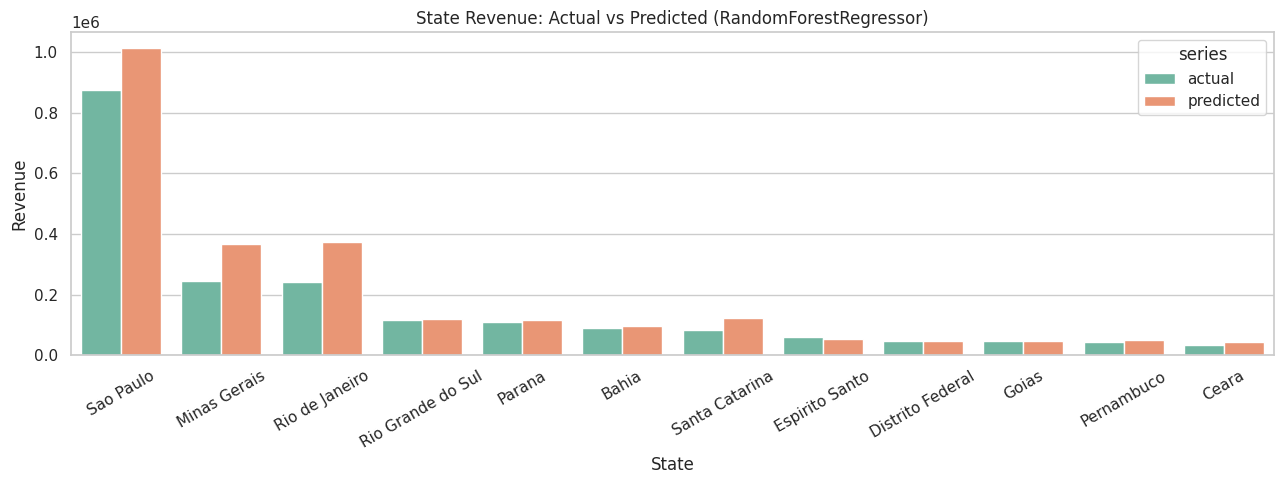

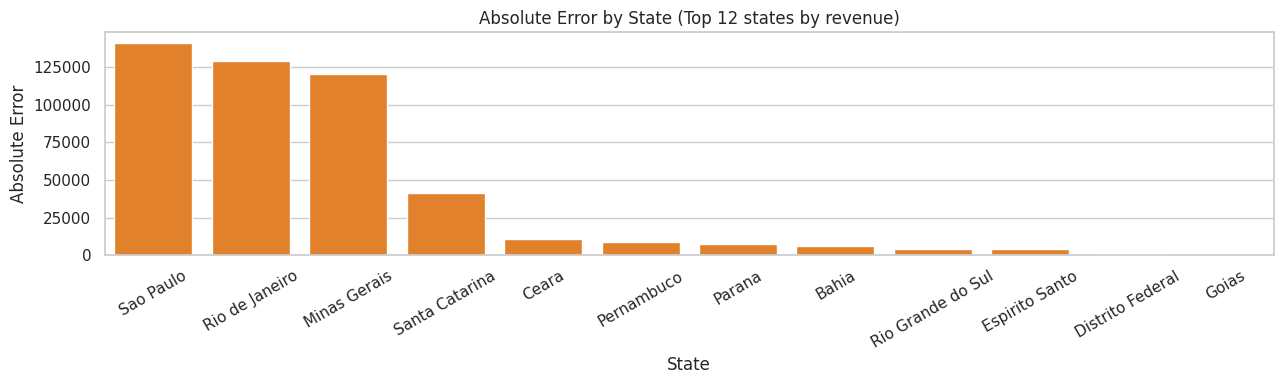

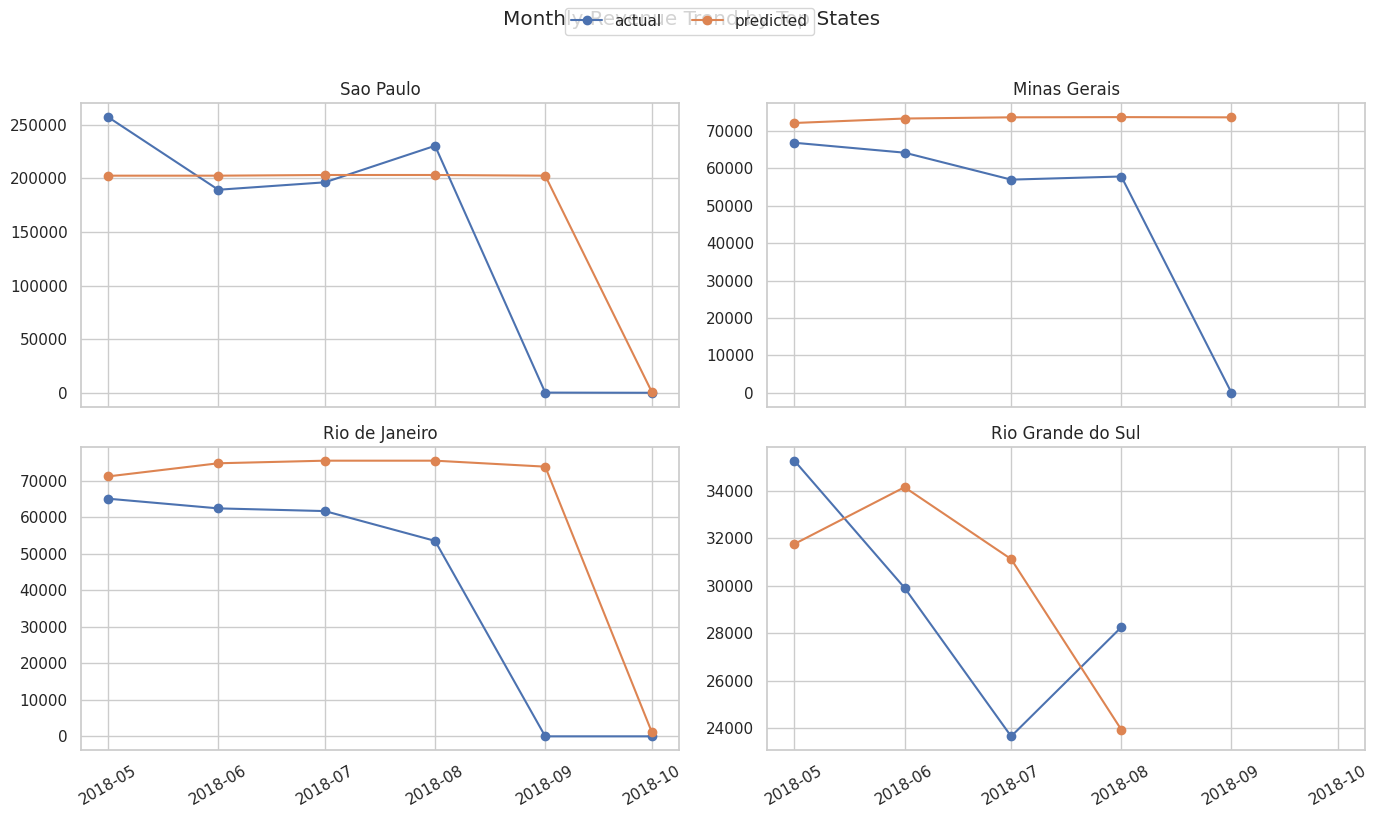

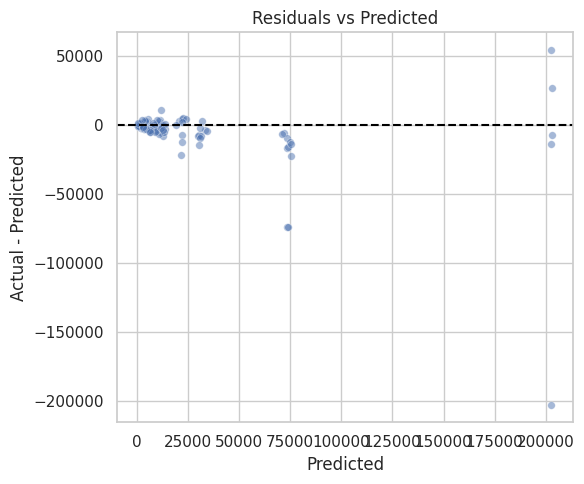

In [31]:
# Purpose: detailed regression diagnostics with practical, readable visualizations.
# 1) Pick best model from comparison table.
best_reg_model = df_reg_results.iloc[0]["model"]
reg_test_plot = test.copy()
reg_test_plot["predicted"] = preds_reg[best_reg_model]

# 2) State-level totals: actual vs predicted.
state_compare = reg_test_plot.groupby("customer_state", as_index=False).agg(
    actual=("total_order_value", "sum"),
    predicted=("predicted", "sum"),
)
state_compare["abs_error"] = (state_compare["actual"] - state_compare["predicted"]).abs()
state_compare = state_compare.sort_values("actual", ascending=False).head(12)
state_melt = state_compare.melt(
    id_vars="customer_state",
    value_vars=["actual", "predicted"],
    var_name="series",
    value_name="sales",
)

plt.figure(figsize=(13, 5))
sns.barplot(data=state_melt, x="customer_state", y="sales", hue="series", palette="Set2")
plt.title(f"State Revenue: Actual vs Predicted ({best_reg_model})")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3) Error concentration by state.
plt.figure(figsize=(13, 4))
err_plot = state_compare.sort_values("abs_error", ascending=False)
sns.barplot(data=err_plot, x="customer_state", y="abs_error", color="tab:orange")
plt.title("Absolute Error by State (Top 12 states by revenue)")
plt.xlabel("State")
plt.ylabel("Absolute Error")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 4) Time trend for top states to check tracking quality.
top_states = state_compare["customer_state"].head(4).tolist()
trend_plot = reg_test_plot[reg_test_plot["customer_state"].isin(top_states)].copy()
trend_monthly = trend_plot.groupby(["order_month", "customer_state"], as_index=False).agg(
    actual=("total_order_value", "sum"),
    predicted=("predicted", "sum"),
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
for ax, state in zip(axes.flatten(), top_states):
    d = trend_monthly[trend_monthly["customer_state"] == state]
    ax.plot(d["order_month"], d["actual"], marker="o", label="actual")
    ax.plot(d["order_month"], d["predicted"], marker="o", label="predicted")
    ax.set_title(state)
    ax.tick_params(axis="x", rotation=30)

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)
fig.suptitle("Monthly Revenue Trend by Top States", y=1.02)
plt.tight_layout()
plt.show()

# 5) Residual scatter to detect bias (over/under prediction pattern).
residual_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": preds_reg[best_reg_model],
})
residual_df["residual"] = residual_df["actual"] - residual_df["predicted"]

plt.figure(figsize=(6, 5))
sns.scatterplot(data=residual_df, x="predicted", y="residual", alpha=0.5, s=30)
plt.axhline(0, linestyle="--", color="black")
plt.title("Residuals vs Predicted")
plt.xlabel("Predicted")
plt.ylabel("Actual - Predicted")
plt.tight_layout()
plt.show()

## "5. Supervised Learning Module" - "Binary Classification"
<div style="font-size:14px; line-height:1.6">
Use case: predict "is_late" using "LogisticRegression" with "leakage-safe" features and "time-based" split.
</div>

In [8]:
# Purpose: late-delivery model with leakage-safe features and realistic validation.
# Libraries: pandas, scikit-learn.

df_binary = (
    df_model.groupby("order_id", as_index=False)
    .agg(
        order_purchase_timestamp=("order_purchase_timestamp", "first"),
        order_delivered_customer_date=("order_delivered_customer_date", "first"),
        order_estimated_delivery_date=("order_estimated_delivery_date", "first"),
        freight_value=("freight_value", "mean"),
        product_weight_g=("product_weight_g", "mean"),
        customer_state=("customer_state", "first"),
        seller_state=("seller_state", "first"),
        customer_city=("customer_city", "first"),
        seller_city=("seller_city", "first"),
    )
)

df_binary = df_binary.dropna(subset=[
    "order_purchase_timestamp", "order_delivered_customer_date", "order_estimated_delivery_date"
]).copy()

df_binary["is_late"] = (df_binary["order_delivered_customer_date"] > df_binary["order_estimated_delivery_date"]).astype(int)
df_binary["estimated_delivery_days"] = (
    df_binary["order_estimated_delivery_date"] - df_binary["order_purchase_timestamp"]
).dt.days
df_binary["is_interstate_delivery"] = (df_binary["customer_state"] != df_binary["seller_state"]).astype(int)

binary_features = [
    "freight_value", "product_weight_g", "estimated_delivery_days", "is_interstate_delivery",
    "customer_state", "seller_state", "customer_city", "seller_city",
]
X_binary = df_binary[binary_features].copy()
y_binary = df_binary["is_late"].copy()

split_date_binary = df_binary["order_purchase_timestamp"].quantile(0.8)
train_mask_binary = df_binary["order_purchase_timestamp"] <= split_date_binary

X_train_binary = X_binary[train_mask_binary].copy()
X_test_binary = X_binary[~train_mask_binary].copy()
y_train_binary = y_binary[train_mask_binary].copy()
y_test_binary = y_binary[~train_mask_binary].copy()

num_binary = ["freight_value", "product_weight_g", "estimated_delivery_days", "is_interstate_delivery"]
cat_binary = ["customer_state", "seller_state", "customer_city", "seller_city"]

prep_binary = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_binary,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_binary,
        ),
    ]
)

binary_model = Pipeline([
    ("prep", prep_binary),
    ("model", LogisticRegression(max_iter=800, class_weight="balanced", random_state=42)),
])
binary_model.fit(X_train_binary, y_train_binary)

y_pred_binary = binary_model.predict(X_test_binary)
y_prob_binary = binary_model.predict_proba(X_test_binary)[:, 1]

metrics_bin = {
    "accuracy": accuracy_score(y_test_binary, y_pred_binary),
    "precision": precision_recall_fscore_support(y_test_binary, y_pred_binary, average="binary")[0],
    "recall": precision_recall_fscore_support(y_test_binary, y_pred_binary, average="binary")[1],
    "f1": precision_recall_fscore_support(y_test_binary, y_pred_binary, average="binary")[2],
    "roc_auc": roc_auc_score(y_test_binary, y_prob_binary),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1_binary = cross_val_score(binary_model, X_train_binary, y_train_binary, cv=cv, scoring="f1")
cv_auc_binary = cross_val_score(binary_model, X_train_binary, y_train_binary, cv=cv, scoring="roc_auc")

cv_bin_summary = pd.DataFrame({
    "metric": ["f1", "roc_auc"],
    "cv_mean": [cv_f1_binary.mean(), cv_auc_binary.mean()],
    "cv_std": [cv_f1_binary.std(), cv_auc_binary.std()],
})

print("binary holdout metrics:")
print(metrics_bin)
print("\nbinary train-CV summary:")
display(cv_bin_summary)

binary holdout metrics:
{'accuracy': 0.6122291766971594, 'precision': 0.09043805934997645, 'recall': 0.6994535519125683, 'f1': 0.16016684045881127, 'roc_auc': 0.6957492679580828}

binary train-CV summary:


,metric,cv_mean,cv_std
0,f1,0.260011,0.006655
1,roc_auc,0.705778,0.008001


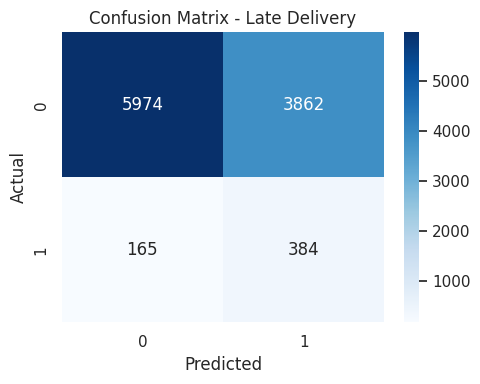

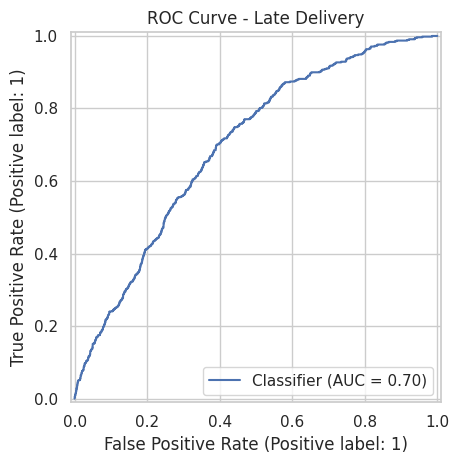

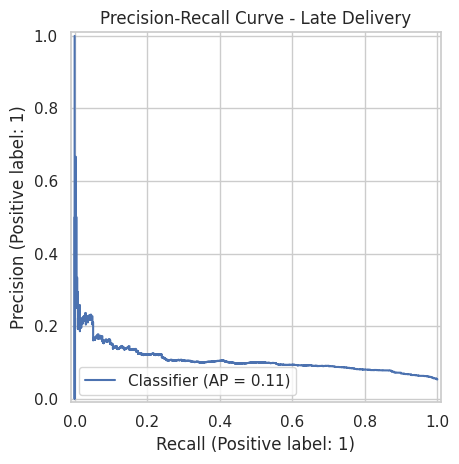

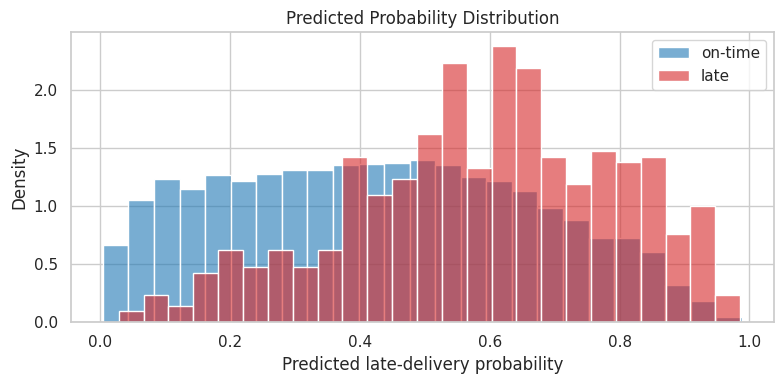

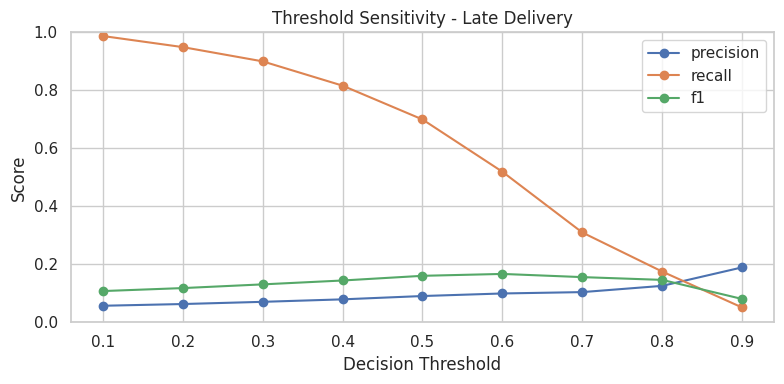

              precision    recall  f1-score   support

           0       0.97      0.61      0.75      9836
           1       0.09      0.70      0.16       549

    accuracy                           0.61     10385
   macro avg       0.53      0.65      0.45     10385
weighted avg       0.93      0.61      0.72     10385

CV mean F1: 0.26
CV mean ROC-AUC: 0.7058


In [9]:
# Purpose: readable binary diagnostics (confusion matrix, ROC, PR, score distribution).
# 1) Confusion matrix for error type visibility.
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_binary, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Late Delivery")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2) ROC curve for threshold-independent ranking quality.
RocCurveDisplay.from_predictions(y_test_binary, y_prob_binary)
plt.title("ROC Curve - Late Delivery")
plt.tight_layout()
plt.show()

# 3) Precision-Recall curve for imbalance-sensitive quality.
PrecisionRecallDisplay.from_predictions(y_test_binary, y_prob_binary)
plt.title("Precision-Recall Curve - Late Delivery")
plt.tight_layout()
plt.show()

# 4) Probability distribution by class.
plt.figure(figsize=(8, 4))
sns.histplot(y_prob_binary[y_test_binary == 0], color="tab:blue", label="on-time", bins=25, alpha=0.6, stat="density")
sns.histplot(y_prob_binary[y_test_binary == 1], color="tab:red", label="late", bins=25, alpha=0.6, stat="density")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted late-delivery probability")
plt.legend()
plt.tight_layout()
plt.show()

# 5) Threshold sensitivity chart (precision/recall/f1 vs threshold).
thresholds = np.linspace(0.1, 0.9, 9)
rows = []
for t in thresholds:
    pred_t = (y_prob_binary >= t).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(y_test_binary, pred_t, average="binary", zero_division=0)
    rows.append({"threshold": t, "precision": p, "recall": r, "f1": f1})

df_thr = pd.DataFrame(rows)
plt.figure(figsize=(8, 4))
plt.plot(df_thr["threshold"], df_thr["precision"], marker="o", label="precision")
plt.plot(df_thr["threshold"], df_thr["recall"], marker="o", label="recall")
plt.plot(df_thr["threshold"], df_thr["f1"], marker="o", label="f1")
plt.title("Threshold Sensitivity - Late Delivery")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

print(classification_report(y_test_binary, y_pred_binary))
print("CV mean F1:", round(cv_bin_summary.loc[cv_bin_summary["metric"] == "f1", "cv_mean"].iloc[0], 4))
print("CV mean ROC-AUC:", round(cv_bin_summary.loc[cv_bin_summary["metric"] == "roc_auc", "cv_mean"].iloc[0], 4))

### Unsupervised Learning Module - Multiclass Classification
<div style="font-size:14px; line-height:1.6">
Use case: predict payment preference with "leakage-safe" features and "time-based" split.
</div>

In [10]:
# Purpose: multiclass payment-type modeling with leakage-safe feature set.
# Libraries: pandas, scikit-learn.

order_pay_mode = (
    df_model.dropna(subset=["payment_type"])
    .groupby("order_id")["payment_type"]
    .agg(lambda s: s.value_counts().index[0])
    .rename("payment_type_major")
)

df_multi = (
    df_model.groupby("order_id", as_index=False)
    .agg(
        order_purchase_timestamp=("order_purchase_timestamp", "first"),
        freight_value=("freight_value", "mean"),
        price=("price", "mean"),
        product_weight_g=("product_weight_g", "mean"),
        customer_state=("customer_state", "first"),
        seller_state=("seller_state", "first"),
        customer_city=("customer_city", "first"),
        seller_city=("seller_city", "first"),
        product_category_name_english=("product_category_name_english", "first"),
    )
    .merge(order_pay_mode.reset_index(), on="order_id", how="inner")
)

valid_classes = df_multi["payment_type_major"].value_counts()
valid_classes = valid_classes[valid_classes >= 150].index
df_multi = df_multi[df_multi["payment_type_major"].isin(valid_classes)].copy()

feature_cols_multi = [
    "freight_value", "price", "product_weight_g",
    "customer_state", "seller_state", "customer_city", "seller_city", "product_category_name_english",
]

X_multi = df_multi[feature_cols_multi].copy()
y_multi = df_multi["payment_type_major"].copy()

split_date_multi = df_multi["order_purchase_timestamp"].quantile(0.8)
train_mask_multi = df_multi["order_purchase_timestamp"] <= split_date_multi

X_train_multi = X_multi[train_mask_multi].copy()
X_test_multi = X_multi[~train_mask_multi].copy()
y_train_multi = y_multi[train_mask_multi].copy()
y_test_multi = y_multi[~train_mask_multi].copy()

num_cols_multi = ["freight_value", "price", "product_weight_g"]
cat_cols_multi = ["customer_state", "seller_state", "customer_city", "seller_city", "product_category_name_english"]

prep_multi = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols_multi,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore")),
            ]),
            cat_cols_multi,
        ),
    ]
)

models_multi = {
    "LogisticRegression": LogisticRegression(max_iter=800, random_state=42),
    "DecisionTree": DecisionTreeClassifier(max_depth=20, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=RF_TREES_FAST, max_depth=20, random_state=42, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_neighbors=11),
}

rows_multi = []
for name, model in models_multi.items():
    clf = Pipeline([("prep", prep_multi), ("model", model)])
    clf.fit(X_train_multi, y_train_multi)
    y_pred = clf.predict(X_test_multi)
    y_proba = clf.predict_proba(X_test_multi)

    p, r, f1, _ = precision_recall_fscore_support(y_test_multi, y_pred, average="weighted", zero_division=0)
    roc_auc_multi = roc_auc_score(
        y_test_multi,
        y_proba,
        multi_class="ovr",
        average="weighted",
        labels=clf.classes_,
    )
    rows_multi.append({
        "model": name,
        "accuracy": accuracy_score(y_test_multi, y_pred),
        "precision": p,
        "recall": r,
        "f1": f1,
        "roc_auc": roc_auc_multi,
    })

df_multi_results = pd.DataFrame(rows_multi).sort_values("f1", ascending=False)

best_multi_model_name = df_multi_results.iloc[0]["model"]
best_multi_model = Pipeline([
    ("prep", prep_multi),
    ("model", models_multi[best_multi_model_name]),
])
best_multi_model.fit(X_train_multi, y_train_multi)
y_pred_multi = best_multi_model.predict(X_test_multi)
y_proba_multi = best_multi_model.predict_proba(X_test_multi)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_multi_f1 = cross_val_score(best_multi_model, X_train_multi, y_train_multi, cv=cv, scoring="f1_weighted")
cv_multi_summary = pd.DataFrame({
    "metric": ["f1_weighted"],
    "cv_mean": [cv_multi_f1.mean()],
    "cv_std": [cv_multi_f1.std()],
})

print("best multiclass model:", best_multi_model_name)
print("multiclass train-CV mean F1:", round(cv_multi_f1.mean(), 4))
df_multi_results

best multiclass model: KNN
multiclass train-CV mean F1: 0.6533


,model,accuracy,precision,recall,f1,roc_auc
3,KNN,0.740166,0.612525,0.740166,0.649193,0.520277
0,LogisticRegression,0.746800,0.614141,0.746800,0.645808,0.550731
1,DecisionTree,0.728768,0.602889,0.728768,0.644406,0.540268
2,RandomForest,0.749977,0.562465,0.749977,0.642826,0.557960


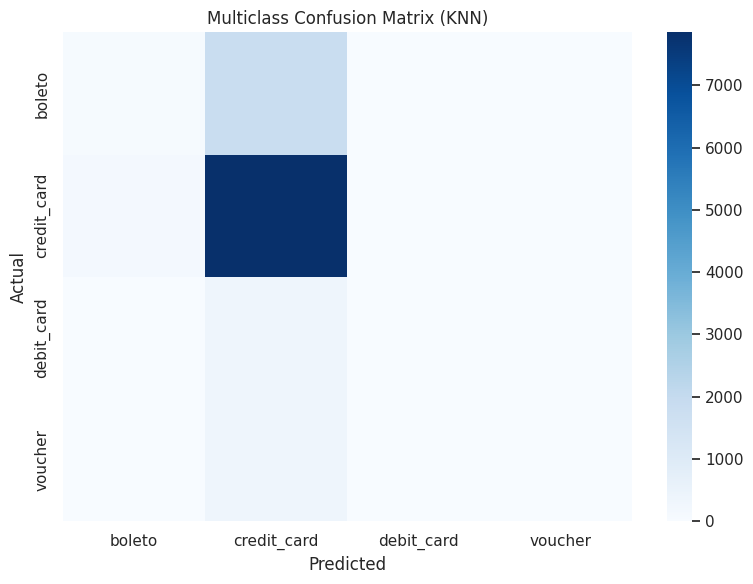

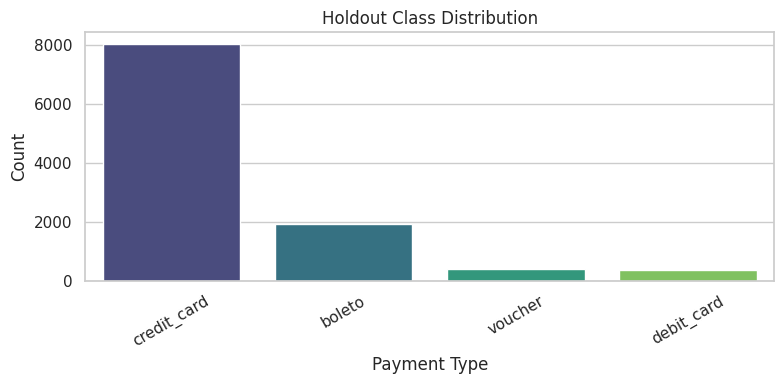

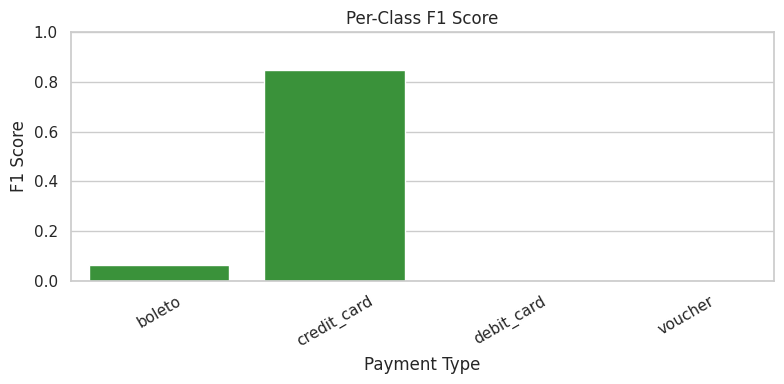

              precision    recall  f1-score   support

      boleto       0.27      0.04      0.06      1933
 credit_card       0.75      0.98      0.85      8027
  debit_card       0.00      0.00      0.00       358
     voucher       0.00      0.00      0.00       385

    accuracy                           0.74     10703
   macro avg       0.26      0.25      0.23     10703
weighted avg       0.61      0.74      0.65     10703



In [11]:
# Purpose: visualize multiclass model behavior.
# 1) Confusion matrix for best model.
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, labels=sorted(y_test_multi.unique()))
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_multi,
    cmap="Blues",
    xticklabels=sorted(y_test_multi.unique()),
    yticklabels=sorted(y_test_multi.unique()),
)
plt.title(f"Multiclass Confusion Matrix ({best_multi_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 2) Holdout class distribution to explain imbalance.
class_support = y_test_multi.value_counts().sort_values(ascending=False)
plt.figure(figsize=(8, 4))
sns.barplot(x=class_support.index, y=class_support.values, palette="viridis")
plt.title("Holdout Class Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# 3) Per-class F1 from classification report for practical insight.
report_multi = classification_report(y_test_multi, y_pred_multi, zero_division=0, output_dict=True)
df_cls = (
    pd.DataFrame(report_multi)
    .T
    .reset_index()
    .rename(columns={"index": "class"})
)
df_cls = df_cls[~df_cls["class"].isin(["accuracy", "macro avg", "weighted avg"])].copy()

plt.figure(figsize=(8, 4))
sns.barplot(data=df_cls, x="class", y="f1-score", color="tab:green")
plt.title("Per-Class F1 Score")
plt.xlabel("Payment Type")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(classification_report(y_test_multi, y_pred_multi, zero_division=0))

## "6. Clustering Module"
<div style="font-size:14px; line-height:1.6">
Use case: "Customer Segmentation" using "RFM" + "KMeans".
</div>

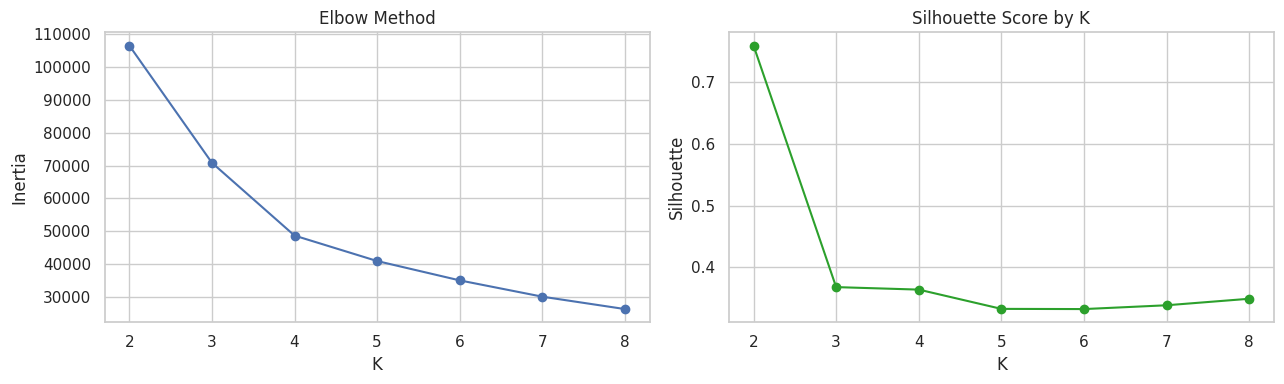

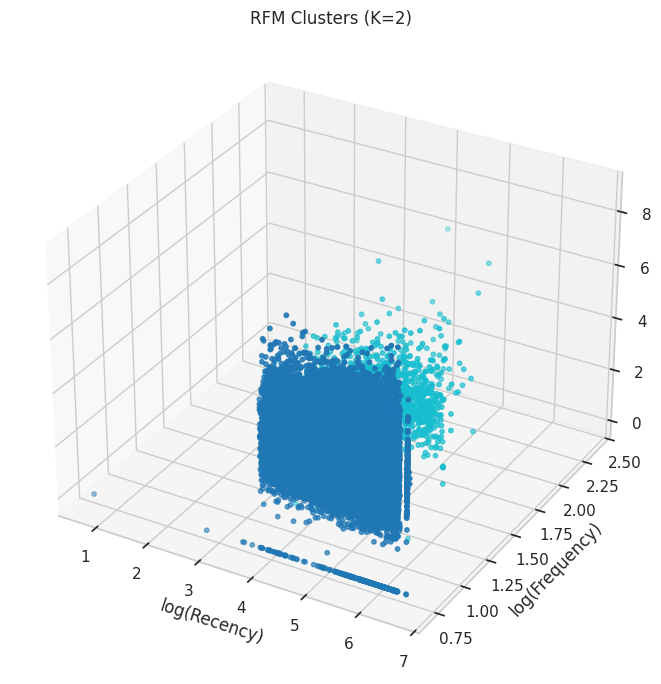

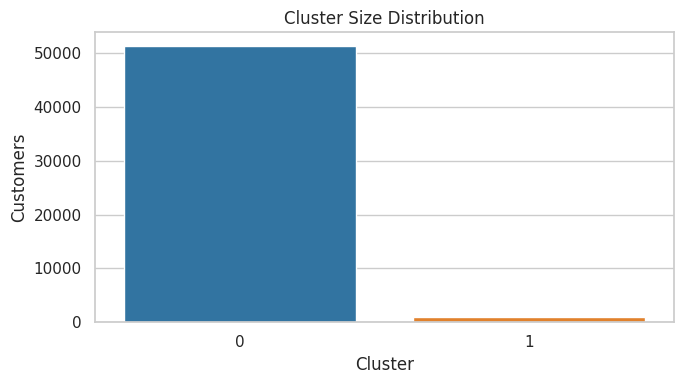

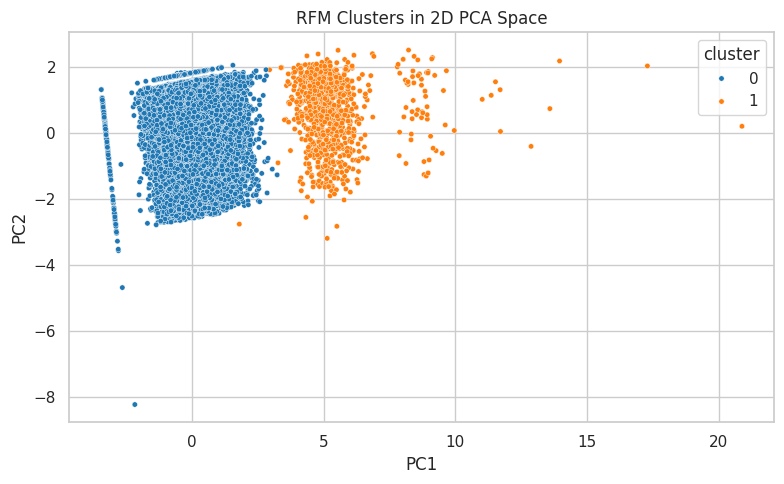

In [ ]:
# Purpose: build RFM features, fit KMeans, and create clustering visuals.
# 1) Build RFM base table from sampled modeling data.
rfm_base = df_model[["customer_unique_id", "order_id", "order_purchase_timestamp", "price"]].dropna(
    subset=["customer_unique_id", "order_id", "order_purchase_timestamp"]
)

snapshot_date = rfm_base["order_purchase_timestamp"].max() + pd.Timedelta(days=1)

# 2) Compute Recency, Frequency, Monetary.
df_rfm = (
    rfm_base.groupby("customer_unique_id")
    .agg(
        Recency=("order_purchase_timestamp", lambda x: (snapshot_date - x.max()).days),
        Frequency=("order_id", "nunique"),
        Monetary=("price", "sum"),
    )
    .reset_index()
)

# 3) Log-transform skewed RFM distributions.
for col in ["Recency", "Frequency", "Monetary"]:
    df_rfm[f"log_{col}"] = np.log1p(df_rfm[col])

# 4) Scale and search best K using elbow + silhouette.
X_rfm = df_rfm[["log_Recency", "log_Frequency", "log_Monetary"]].copy()
rfm_scaler = StandardScaler()
X_rfm_scaled = rfm_scaler.fit_transform(X_rfm)

k_values = list(range(2, KMEANS_MAX_K + 1))
inertia_vals, sil_vals = [], []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_scaled)
    inertia_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_values, inertia_vals, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_values, sil_vals, marker="o", color="tab:green")
axes[1].set_title("Silhouette Score by K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

# 5) Fit final KMeans model.
best_k = k_values[int(np.argmax(sil_vals))]
model_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_rfm["cluster"] = model_km.fit_predict(X_rfm_scaled)

# 6) 3D visualization.
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    df_rfm["log_Recency"],
    df_rfm["log_Frequency"],
    df_rfm["log_Monetary"],
    c=df_rfm["cluster"],
    cmap="tab10",
    s=10,
)
ax.set_xlabel("log(Recency)")
ax.set_ylabel("log(Frequency)")
ax.set_zlabel("log(Monetary)")
ax.set_title(f"RFM Clusters (K={best_k})")
plt.tight_layout()
plt.show()

# 7) Cluster size distribution.
cluster_size = df_rfm["cluster"].value_counts().sort_index()
plt.figure(figsize=(7, 4))
sns.barplot(x=cluster_size.index, y=cluster_size.values, palette="tab10")
plt.title("Cluster Size Distribution")
plt.xlabel("Cluster")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

# 8) 2D PCA projection.
pca = PCA(n_components=2, random_state=42)
rfm_2d = pca.fit_transform(X_rfm_scaled)

plt.figure(figsize=(8, 5))
sns.scatterplot(x=rfm_2d[:, 0], y=rfm_2d[:, 1], hue=df_rfm["cluster"], palette="tab10", s=15)
plt.title("RFM Clusters in 2D PCA Space")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

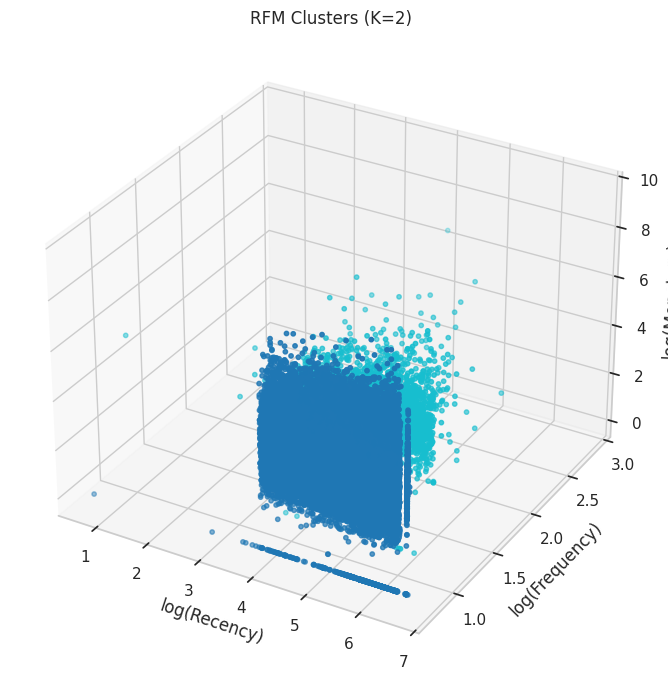

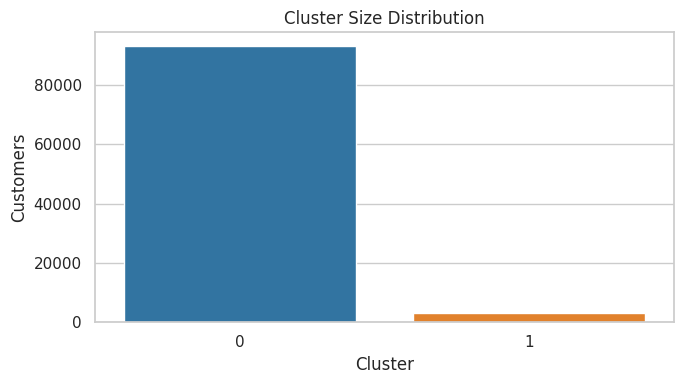

In [ ]:
# Purpose: show business-friendly cluster profile summary.
cluster_profile = df_rfm.groupby("cluster")[["Recency", "Frequency", "Monetary"]].mean().round(2)
cluster_profile["customers"] = df_rfm["cluster"].value_counts().sort_index().values
cluster_profile = cluster_profile.reset_index().sort_values("cluster")

display(cluster_profile)

## "7. NLP Module"
<div style="font-size:14px; line-height:1.6">
Use cases: "Sentiment Analysis" + "Root Cause Analysis" of negative reviews.
</div>

In [ ]:
# Purpose: clean review text and generate sentiment labels with VADER.
# Libraries: nltk, pandas, sklearn (later for TF-IDF).
df_nlp = df_model[["review_comment_message", "review_score"]].dropna(subset=["review_comment_message"]).copy()
df_nlp = df_nlp[df_nlp["review_comment_message"].str.strip().ne("")]

# Sample NLP rows again for faster vectorization.
df_nlp = df_nlp.sample(frac=min(1.0, TRAIN_SAMPLE_FRAC), random_state=42)

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [t for t in word_tokenize(text) if t.isalpha() and t not in stop_words]
    return " ".join(tokens)

df_nlp["clean_text"] = df_nlp["review_comment_message"].apply(clean_text)
df_nlp = df_nlp[df_nlp["clean_text"].str.len() > 0]

sia = SentimentIntensityAnalyzer()
df_nlp["vader_score"] = df_nlp["clean_text"].apply(lambda x: sia.polarity_scores(x)["compound"])

df_nlp["sentiment"] = np.select(
    [df_nlp["vader_score"] >= 0.05, df_nlp["vader_score"] <= -0.05],
    ["positive", "negative"],
    default="neutral",
)

df_nlp["actual_sentiment"] = pd.cut(df_nlp["review_score"], bins=[0, 2, 3, 5], labels=["negative", "neutral", "positive"])

print("nlp rows:", len(df_nlp))
df_nlp.head(3)

nlp rows: 50004


,review_comment_message,review_score,clean_text,vader_score,sentiment,actual_sentiment
0,"Não testei o produto ainda, mas ele veio corre...",4.0,não testei produto ainda mas ele veio correto ...,0.0,neutral,positive
1,"Não testei o produto ainda, mas ele veio corre...",4.0,não testei produto ainda mas ele veio correto ...,0.0,neutral,positive
2,"Não testei o produto ainda, mas ele veio corre...",4.0,não testei produto ainda mas ele veio correto ...,0.0,neutral,positive


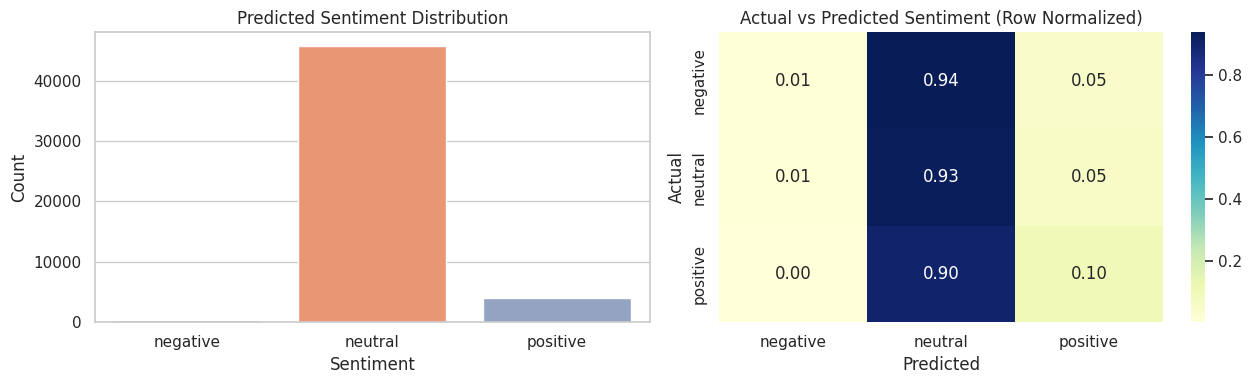

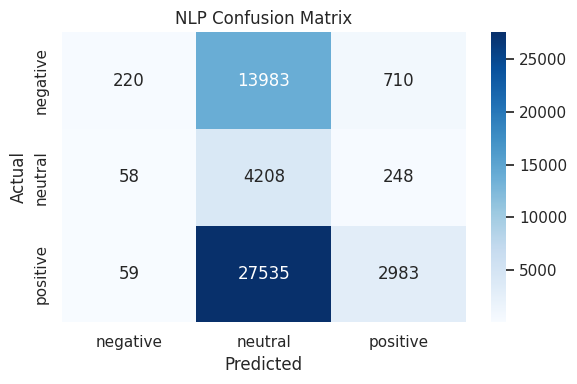

NLP metrics summary


,accuracy,precision,recall,f1
0,0.148208,0.665848,0.148208,0.129415


              precision    recall  f1-score   support

    negative       0.65      0.01      0.03     14913
     neutral       0.09      0.93      0.17      4514
    positive       0.76      0.10      0.17     30577

    accuracy                           0.15     50004
   macro avg       0.50      0.35      0.12     50004
weighted avg       0.67      0.15      0.13     50004



In [ ]:
# Purpose: show sentiment distribution and full YAML metrics vs review-score labels.
# 1) Side-by-side distribution and agreement heatmap.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=df_nlp, x="sentiment", order=["negative", "neutral", "positive"], palette="Set2", ax=axes[0])
axes[0].set_title("Predicted Sentiment Distribution")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")

# Practical check: agreement between review-score sentiment and model sentiment.
df_cmp = df_nlp.dropna(subset=["actual_sentiment"]).copy()
conf_norm = pd.crosstab(df_cmp["actual_sentiment"], df_cmp["sentiment"], normalize="index")
sns.heatmap(conf_norm, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Actual vs Predicted Sentiment (Row Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# 2) Score distribution by predicted sentiment.
plt.figure(figsize=(8, 4))
sns.kdeplot(data=df_nlp, x="vader_score", hue="sentiment", fill=True, common_norm=False, alpha=0.25)
plt.title("VADER Score Distribution by Predicted Sentiment")
plt.xlabel("VADER Compound Score")
plt.tight_layout()
plt.show()

# 3) YAML metrics for NLP: accuracy, precision, recall, f1, confusion matrix.
nlp_accuracy = accuracy_score(df_cmp["actual_sentiment"], df_cmp["sentiment"])
nlp_p, nlp_r, nlp_f1, _ = precision_recall_fscore_support(
    df_cmp["actual_sentiment"],
    df_cmp["sentiment"],
    average="weighted",
    zero_division=0,
)
nlp_metrics = pd.DataFrame([
    {
        "accuracy": nlp_accuracy,
        "precision": nlp_p,
        "recall": nlp_r,
        "f1": nlp_f1,
    }
])

cm_nlp = confusion_matrix(
    df_cmp["actual_sentiment"],
    df_cmp["sentiment"],
    labels=["negative", "neutral", "positive"],
)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"],
)
plt.title("NLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("NLP metrics summary")
display(nlp_metrics)
print(classification_report(df_cmp["actual_sentiment"], df_cmp["sentiment"], zero_division=0))

In [ ]:
# Purpose: cluster negative reviews into topic groups using TF-IDF + KMeans.
neg = df_nlp[df_nlp["sentiment"] == "negative"].copy()

if len(neg) > 50:
    vec = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=5)
    X_tfidf = vec.fit_transform(neg["clean_text"])

    topic_k = 5
    km = KMeans(n_clusters=topic_k, random_state=42, n_init=20)
    neg["topic_cluster"] = km.fit_predict(X_tfidf)

    terms = np.array(vec.get_feature_names_out())
    for i, center in enumerate(km.cluster_centers_):
        top_idx = center.argsort()[::-1][:10]
        print(f"cluster {i}:", ", ".join(terms[top_idx]))
else:
    print("not enough negative reviews for stable topic clustering")

cluster 0: chegou, anti, que chegou, foi, para, dos, que, na propaganda, produto, não
cluster 1: não, de, um, que, comprei, propaganda, enganosa, propaganda enganosa, produto, com
cluster 2: muito, produto, inferior, com, bem, qualidade, propaganda, de, prazo, muito inferior
cluster 3: inferior ao, ao, inferior, ao que, produto inferior, produto, qualidade, que, qualidade produto, qualidade inferior
cluster 4: por motivo, greve, de greve, greve doa, nao chegou, entendo que, entendo, motivo de, chegou por, doa correios


In [ ]:
# # Purpose: optional NER example using transformers if installed.
# if TRANSFORMERS_AVAILABLE:
#     try:
#         ner = pipeline("ner", grouped_entities=True)
#         for i, text in enumerate(df_nlp["review_comment_message"].head(3), 1):
#             ents = ner(str(text))
#             print(f"review {i} entities:", [(e.get("word"), e.get("entity_group")) for e in ents[:8]])
#     except Exception as e:
#         print("NER unavailable:", e)
# else:
#     print("transformers not installed; skipping NER")

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496.
Using a pipeline without specifying a model name and revision in production is not recommended.


NER unavailable: name 'torch' is not defined


## "8. Time Series Module"
<div style="font-size:14px; line-height:1.6">
Use case: forecast order volume using "ARIMA", "SARIMA", and "Prophet".
</div>

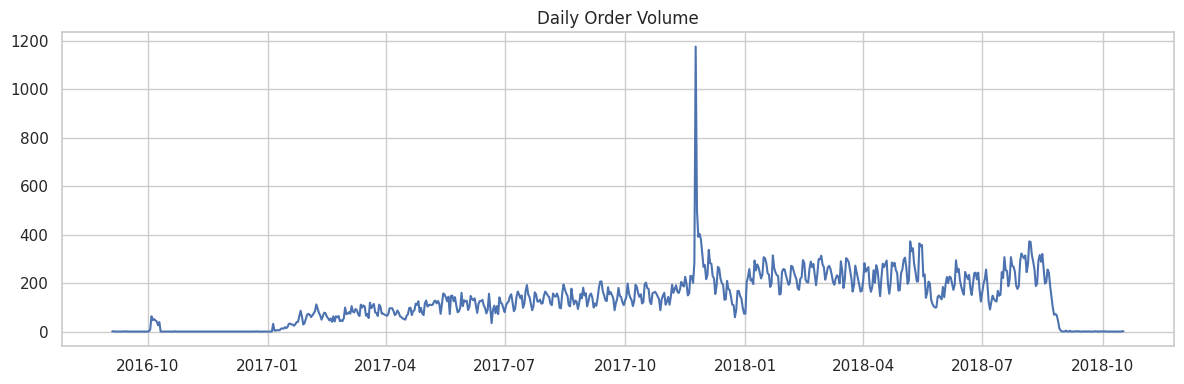

ADF statistic: -2.3217
p-value: 0.1651


In [ ]:
# Purpose: build daily order volume series and run stationarity check.
# Libraries: pandas, statsmodels.
df_ts = df_orders[["order_id", "order_purchase_timestamp"]].copy()
df_ts["order_purchase_timestamp"] = pd.to_datetime(df_ts["order_purchase_timestamp"], errors="coerce")
df_ts = df_ts.dropna(subset=["order_purchase_timestamp"])

series_daily = (
    df_ts.set_index("order_purchase_timestamp")
    .resample("D")["order_id"]
    .nunique()
    .rename("order_volume")
)

plt.figure(figsize=(12, 4))
plt.plot(series_daily.index, series_daily.values)
plt.title("Daily Order Volume")
plt.tight_layout()
plt.show()

adf_stat, adf_pvalue, *_ = adfuller(series_daily.dropna())
print("ADF statistic:", round(adf_stat, 4))
print("p-value:", round(adf_pvalue, 4))

In [ ]:
# Purpose: train forecasting models and compare MAE/RMSE.
horizon = 90
train_ts = series_daily.iloc[:-horizon]
test_ts = series_daily.iloc[-horizon:]

model_arima = ARIMA(train_ts, order=(1, 1, 1)).fit()
pred_arima = model_arima.forecast(steps=horizon)

model_sarima = SARIMAX(train_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7)).fit(disp=False)
pred_sarima = model_sarima.forecast(steps=horizon)

prophet_train = train_ts.reset_index()
prophet_train.columns = ["ds", "y"]
model_prophet = Prophet()
model_prophet.fit(prophet_train)
future = model_prophet.make_future_dataframe(periods=horizon, freq="D")
forecast = model_prophet.predict(future)
pred_prophet = forecast.set_index("ds")["yhat"].iloc[-horizon:]

def score_ts(y_true, y_pred, model_name):
    return {
        "model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
    }

rows = [
    score_ts(test_ts, pred_arima, "ARIMA"),
    score_ts(test_ts, pred_sarima, "SARIMA"),
    score_ts(test_ts, pred_prophet, "Prophet"),
]

df_ts_results = pd.DataFrame(rows).sort_values("RMSE")
df_ts_results

01:47:04 - cmdstanpy - INFO - Chain [1] start processing
01:47:04 - cmdstanpy - INFO - Chain [1] done processing


,model,MAE,RMSE
2,Prophet,132.652768,145.398131
0,ARIMA,143.052377,159.027693
1,SARIMA,146.511538,167.044713


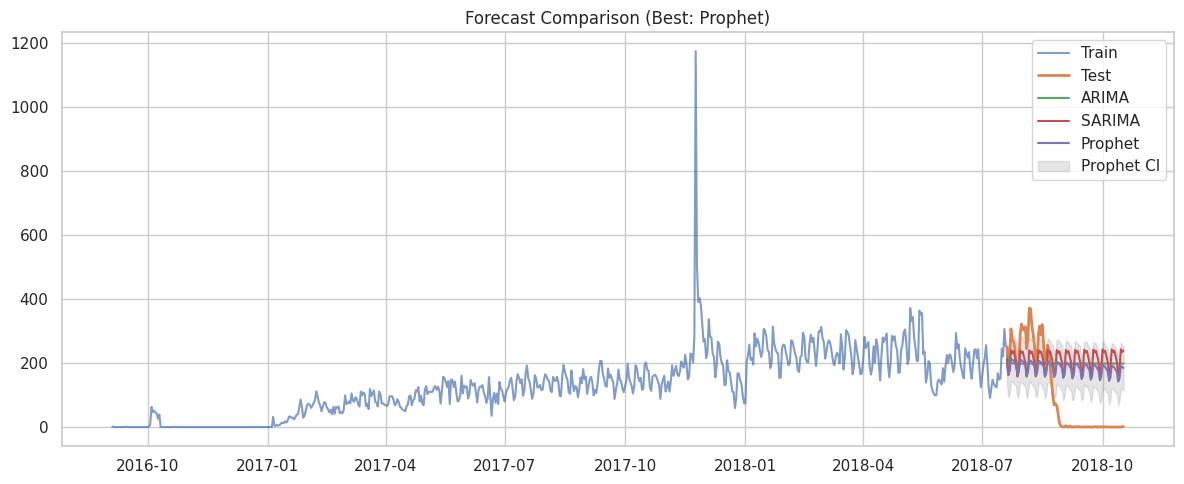

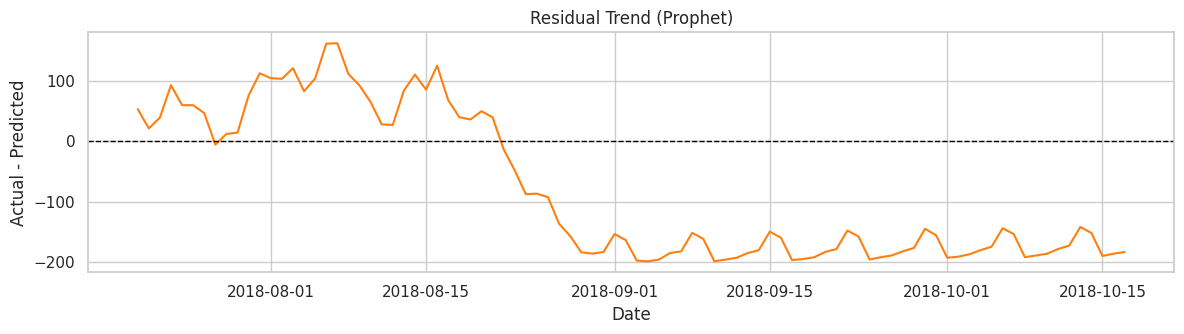

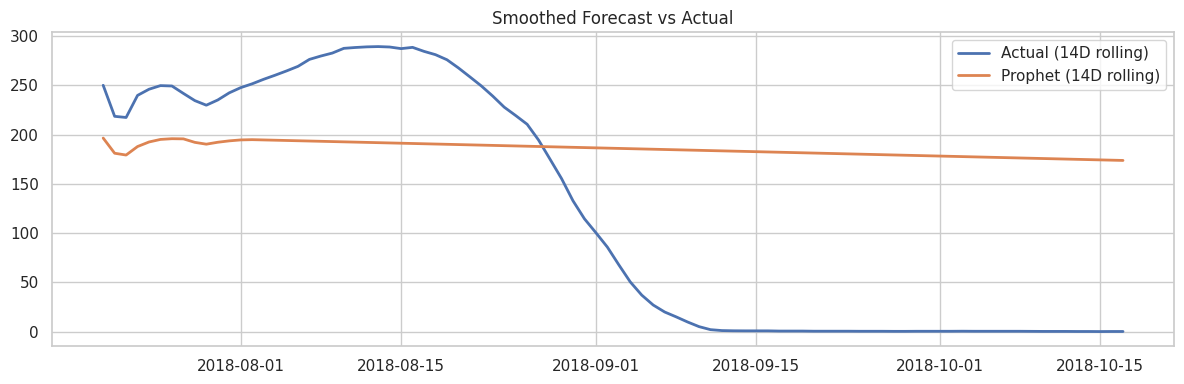

In [25]:
# Purpose: practical forecast visualization with residual diagnostics.
best_name = df_ts_results.iloc[0]["model"]

# 1) Main forecast lines.
plt.figure(figsize=(12, 5))
plt.plot(train_ts.index, train_ts.values, label="Train", alpha=0.7)
plt.plot(test_ts.index, test_ts.values, label="Test", linewidth=2)
plt.plot(test_ts.index, pred_arima.values, label="ARIMA")
plt.plot(test_ts.index, pred_sarima.values, label="SARIMA")
plt.plot(test_ts.index, pred_prophet.values, label="Prophet")

# Add Prophet confidence interval if available in forecast output.
if "yhat_lower" in forecast.columns and "yhat_upper" in forecast.columns:
    ci = forecast.set_index("ds").iloc[-len(test_ts):]
    plt.fill_between(
        test_ts.index,
        ci["yhat_lower"].values,
        ci["yhat_upper"].values,
        color="gray",
        alpha=0.2,
        label="Prophet CI",
    )

plt.title(f"Forecast Comparison (Best: {best_name})")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Residual trend for best model.
best_pred = {
    "ARIMA": pred_arima,
    "SARIMA": pred_sarima,
    "Prophet": pred_prophet,
}[best_name]
residuals = test_ts.values - best_pred.values

plt.figure(figsize=(12, 3.5))
plt.plot(test_ts.index, residuals, color="tab:orange")
plt.axhline(0, linestyle="--", color="black", linewidth=1)
plt.title(f"Residual Trend ({best_name})")
plt.xlabel("Date")
plt.ylabel("Actual - Predicted")
plt.tight_layout()
plt.show()

# 3) 14-day rolling comparison for smoother operational signal.
roll_actual = test_ts.rolling(14, min_periods=1).mean()
roll_pred = pd.Series(best_pred.values, index=test_ts.index).rolling(14, min_periods=1).mean()

plt.figure(figsize=(12, 4))
plt.plot(roll_actual.index, roll_actual.values, label="Actual (14D rolling)", linewidth=2)
plt.plot(roll_pred.index, roll_pred.values, label=f"{best_name} (14D rolling)", linewidth=2)
plt.title("Smoothed Forecast vs Actual")
plt.legend()
plt.tight_layout()
plt.show()

## "9. End-to-End ML Pipeline Requirement"
<div style="font-size:14px; line-height:1.6">
This section uses "scikit pipelines" + "cross-validation" on the same leakage-safe multiclass feature set.
</div>

In [ ]:
# Purpose: pipeline + CV evaluation on leakage-safe multiclass training window.
# Libraries: scikit-learn (ColumnTransformer, Pipeline, cross_val_score).

pipe_model = Pipeline([
    ("prep", prep_multi),
    ("model", RandomForestClassifier(n_estimators=RF_TREES_FAST, random_state=42, class_weight="balanced", n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe_model, X_train_multi, y_train_multi, cv=cv, scoring="f1_weighted")

pipe_model.fit(X_train_multi, y_train_multi)
pipe_pred_test = pipe_model.predict(X_test_multi)
pipe_test_f1 = precision_recall_fscore_support(y_test_multi, pipe_pred_test, average="weighted", zero_division=0)[2]

print("Pipeline CV F1 scores:", np.round(cv_scores, 4))
print("Pipeline mean CV F1:", round(cv_scores.mean(), 4))
print("Pipeline holdout F1:", round(pipe_test_f1, 4))

Pipeline CV F1 scores: [0.6466 0.6465 0.6512 0.6459 0.647 ]
Pipeline mean CV F1: 0.6474
Pipeline holdout F1: 0.6545


## Model Export
<div style="font-size:14px; line-height:1.6">
Save trained models to pickle files for reuse.
</div>

In [24]:
# Purpose: export trained models as pickle files.
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

best_reg_name = df_reg_results.iloc[0]["model"]
best_reg_model = models_reg[best_reg_name]

# Save regression with feature schema for dummy-encoded inputs.
with open(artifacts_dir / "regression_model.pkl", "wb") as f:
    pickle.dump({
        "model_name": best_reg_name,
        "model": best_reg_model,
        "feature_columns": list(x_train.columns),
    }, f)

with open(artifacts_dir / "binary_late_delivery_model.pkl", "wb") as f:
    pickle.dump(binary_model, f)

with open(artifacts_dir / "multiclass_payment_model.pkl", "wb") as f:
    pickle.dump(best_multi_model, f)

with open(artifacts_dir / "clustering_kmeans_model.pkl", "wb") as f:
    pickle.dump({
        "model": model_km,
        "scaler": rfm_scaler,
        "k": best_k,
    }, f)

with open(artifacts_dir / "timeseries_models.pkl", "wb") as f:
    pickle.dump({
        "arima": model_arima,
        "sarima": model_sarima,
        "prophet": model_prophet,
    }, f)

print("Saved model artifacts:")
for p in sorted(artifacts_dir.glob("*.pkl")):
    print("-", p)

Saved model artifacts:
- artifacts/binary_late_delivery_model.pkl
- artifacts/clustering_kmeans_model.pkl
- artifacts/multiclass_payment_model.pkl
- artifacts/regression_model.pkl
- artifacts/timeseries_models.pkl


## "10. Deliverables"
<div style="font-size:14px; line-height:1.6">
The summary tables below support the final report and README.
</div>

In [ ]:
# Purpose: print all model comparison outputs in one place.
print("regression comparison")
display(df_reg_results)

print("\nbinary late-delivery metrics")
display(pd.DataFrame([metrics_bin]))
print("binary CV summary")
display(cv_bin_summary)

print("\nmulticlass payment comparison")
display(df_multi_results)
print("multiclass CV summary")
display(cv_multi_summary)

print("\nNLP sentiment metrics")
display(nlp_metrics)

print("\ntime-series comparison")
display(df_ts_results)

regression comparison


,model,MAE,RMSE,R2
0,LinearRegression,16928.690937,56748.390494,0.496629
2,Lasso,16928.692166,56748.396435,0.496629
1,Ridge,16674.752817,56923.230695,0.493523
3,RandomForestRegressor,16507.930170,57641.713620,0.480657



binary late-delivery metrics


,accuracy,precision,recall,f1,roc_auc
0,0.537289,0.090523,0.856024,0.163732,0.722069


binary CV summary


...

,metric,cv_mean,cv_std
0,f1_weighted,0.662127,0.001952



NLP sentiment metrics


,accuracy,precision,recall,f1
0,0.148208,0.665848,0.148208,0.129415



time-series comparison


,model,MAE,RMSE
2,Prophet,132.652768,145.398131
0,ARIMA,143.052377,159.027693
1,SARIMA,146.511538,167.044713
